<a href="https://colab.research.google.com/github/banerjee109/Infotact-Data-Team-2/blob/Soumodeep_EDA/Assignmenet_1_Roughbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy
!python generate_marketing_data.py

python3: can't open file '/content/generate_marketing_data.py': [Errno 2] No such file or directory


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

NUM_USERS = 2000
NUM_DAYS = 90
START_DATE = datetime(2024, 1, 1)

CHANNELS = ['Google_Search', 'Meta_Facebook', 'TikTok', 'LinkedIn', 'Email', 'Organic']
CAMPAIGNS = {
    'Google_Search': ['GSearch_Brand', 'GSearch_Generic', 'GSearch_Competitor'],
    'Meta_Facebook': ['FB_Retargeting', 'FB_Lookalike', 'FB_Awareness'],
    'TikTok': ['TikTok_Video1', 'TikTok_Promo'],
    'LinkedIn': ['LinkedIn_B2B', 'LinkedIn_Lead'],
    'Email': ['Email_Welcome', 'Email_Promo', 'Email_Retention'],
    'Organic': ['Organic_SEO', 'Organic_Direct']
}
UTM_SOURCES = {
    'Google_Search': 'google',
    'Meta_Facebook': 'facebook',
    'TikTok': 'tiktok',
    'LinkedIn': 'linkedin',
    'Email': 'email',
    'Organic': 'organic'
}
PAGES = ['/home', '/product', '/pricing', '/about', '/blog', '/checkout', '/signup']

# FILE 1 - Ad Spend
print("Generating Ad Spend Data...")
ad_spend_rows = []
for day_offset in range(NUM_DAYS):
    date = START_DATE + timedelta(days=day_offset)
    for channel in CHANNELS:
        for campaign in CAMPAIGNS[channel]:
            spend_range = {
                'Google_Search': (500, 3000),
                'Meta_Facebook': (300, 2000),
                'TikTok': (200, 1500),
                'LinkedIn': (400, 2500),
                'Email': (50, 300),
                'Organic': (0, 0)
            }
            low, high = spend_range[channel]
            spend = round(random.uniform(low, high), 2)
            clicks = int(spend / random.uniform(0.5, 3.0)) if spend > 0 else random.randint(50, 500)
            impressions = clicks * random.randint(10, 50)
            ad_spend_rows.append({
                'date': date.strftime('%Y-%m-%d'),
                'channel': channel,
                'campaign': campaign,
                'amount_spent_usd': spend,
                'clicks': clicks,
                'impressions': impressions,
                'cpc': round(spend / clicks, 3) if clicks > 0 else 0
            })
ad_spend_df = pd.DataFrame(ad_spend_rows)
ad_spend_df.to_csv('ad_spend_data.csv', index=False)
print(f"✅ ad_spend_data.csv created — {len(ad_spend_df)} rows")

# FILE 2 - Web Analytics
print("Generating Web Analytics Log...")
web_log_rows = []
user_ids = [f'USR_{str(i).zfill(5)}' for i in range(1, NUM_USERS + 1)]
for user_id in user_ids:
    num_touchpoints = random.randint(1, 5)
    journey_start = START_DATE + timedelta(days=random.randint(0, NUM_DAYS - 10))
    for tp in range(num_touchpoints):
        session_date = journey_start + timedelta(days=random.randint(0, 7))
        channel = random.choices(CHANNELS, weights=[30, 25, 15, 10, 10, 10])[0]
        campaign = random.choice(CAMPAIGNS[channel])
        utm_source = UTM_SOURCES[channel] if random.random() > 0.1 else None
        utm_medium = 'cpc' if channel in ['Google_Search', 'Meta_Facebook', 'TikTok', 'LinkedIn'] else 'email' if channel == 'Email' else 'organic'
        utm_campaign = campaign if random.random() > 0.05 else None
        web_log_rows.append({
            'session_id': f'SES_{random.randint(100000, 999999)}',
            'user_id': user_id,
            'timestamp': session_date.strftime('%Y-%m-%d') + f' {random.randint(0,23):02d}:{random.randint(0,59):02d}:00',
            'channel': channel,
            'utm_source': utm_source,
            'utm_medium': utm_medium,
            'utm_campaign': utm_campaign,
            'page_visited': random.choice(PAGES),
            'session_duration_sec': random.randint(30, 900),
            'device': random.choice(['mobile', 'desktop', 'tablet'])
        })
web_log_df = pd.DataFrame(web_log_rows)
web_log_df.to_csv('web_analytics_log.csv', index=False)
print(f"✅ web_analytics_log.csv created — {len(web_log_df)} rows")

# FILE 3 - CRM
print("Generating CRM Conversion Data...")
crm_rows = []
converting_users = random.sample(user_ids, int(NUM_USERS * 0.30))
for user_id in converting_users:
    user_sessions = web_log_df[web_log_df['user_id'] == user_id]
    if user_sessions.empty:
        continue
    last_session = user_sessions.sort_values('timestamp').iloc[-1]
    conversion_date = pd.to_datetime(last_session['timestamp']) + timedelta(days=random.randint(0, 2))
    revenue = round(random.uniform(20, 500), 2)
    last_channel = last_session['channel']
    crm_rows.append({
        'customer_id': user_id,
        'conversion_date': conversion_date.strftime('%Y-%m-%d'),
        'revenue_usd': revenue,
        'last_touch_channel': last_channel,
        'last_touch_campaign': last_session['utm_campaign'],
        'product_purchased': random.choice(['Basic Plan', 'Pro Plan', 'Enterprise Plan', 'One-Time Purchase']),
        'country': random.choice(['India', 'USA', 'UK', 'Germany', 'Australia', 'Canada'])
    })
crm_df = pd.DataFrame(crm_rows)
crm_df.to_csv('crm_conversion_data.csv', index=False)
print(f"✅ crm_conversion_data.csv created — {len(crm_df)} rows")

Generating Ad Spend Data...
✅ ad_spend_data.csv created — 1350 rows
Generating Web Analytics Log...
✅ web_analytics_log.csv created — 6034 rows
Generating CRM Conversion Data...
✅ crm_conversion_data.csv created — 600 rows


In [4]:
# FILE 3 - CRM Only
import pandas as pd
import numpy as np
import random
from datetime import timedelta

# Ensure necessary data and variables are available if not defined in preceding cells.
# Assuming 'web_analytics_log.csv' has been generated by previous steps.
web_log_df = pd.read_csv('web_analytics_log.csv')
web_log_df['timestamp'] = pd.to_datetime(web_log_df['timestamp']) # Convert timestamp for sorting

user_ids = web_log_df['user_id'].unique().tolist()
NUM_USERS = len(user_ids)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print("Generating CRM Conversion Data...")
crm_rows = []
converting_users = random.sample(user_ids, int(NUM_USERS * 0.30))
for user_id in converting_users:
    user_sessions = web_log_df[web_log_df['user_id'] == user_id]
    if user_sessions.empty:
        continue
    last_session = user_sessions.sort_values('timestamp').iloc[-1]
    conversion_date = pd.to_datetime(last_session['timestamp']) + timedelta(days=random.randint(0, 2))
    revenue = round(random.uniform(20, 500), 2)
    last_channel = last_session['channel']
    crm_rows.append({
        'customer_id': user_id,
        'conversion_date': conversion_date.strftime('%Y-%m-%d'),
        'revenue_usd': revenue,
        'last_touch_channel': last_channel,
        'last_touch_campaign': last_session['utm_campaign'],
        'product_purchased': random.choice(['Basic Plan', 'Pro Plan', 'Enterprise Plan', 'One-Time Purchase']),
        'country': random.choice(['India', 'USA', 'UK', 'Germany', 'Australia', 'Canada'])
    })
crm_df = pd.DataFrame(crm_rows)
crm_df.to_csv('crm_conversion_data.csv', index=False)
print(f"✅ crm_conversion_data.csv created — {len(crm_df)} rows")
print("\n🎉 DONE! Teeno CSV files ban gayi!")
crm_df.head()
crm_df.tail()
crm_df.info()
crm_df.describe()
type(crm_df)
crm_df.shape
crm_df.columns
crm_df.head(25)
##|crm_df["conversion_date"].value_counts()
##crm_df[(crm_df["conversion_date"]=="2024-01-22")]["revenue_usd"]
crm_df.info()
crm_df["conversion_date"]=pd.to_datetime(crm_df["conversion_date"])
crm_df.info()
type(crm_df["conversion_date"])
crm_df["year"] = crm_df["conversion_date"].dt.year
crm_df["month"] = crm_df["conversion_date"].dt.month
crm_df["day"]=crm_df["conversion_date"].dt.day
crm_df[["year","month","day"]]
crm_df["quarter"]=crm_df["conversion_date"].dt.quarter
crm_df[["year","month","day","quarter"]]
crm_df.groupby(["year","quarter","month"])["revenue_usd"].sum().sort_values(ascending=False)
crm_df.groupby("last_touch_channel")["revenue_usd"].sum().sort_values(ascending=False)
crm_df["last_touch_channel"].nunique()

Generating CRM Conversion Data...
✅ crm_conversion_data.csv created — 600 rows

🎉 DONE! Teeno CSV files ban gayi!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          600 non-null    object 
 1   conversion_date      600 non-null    object 
 2   revenue_usd          600 non-null    float64
 3   last_touch_channel   600 non-null    object 
 4   last_touch_campaign  572 non-null    object 
 5   product_purchased    600 non-null    object 
 6   country              600 non-null    object 
dtypes: float64(1), object(6)
memory usage: 32.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          600 non-null    object 
 1   conversion_date     

6

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1350 non-null   object 
 1   channel           1350 non-null   object 
 2   campaign          1350 non-null   object 
 3   amount_spent_usd  1350 non-null   float64
 4   clicks            1350 non-null   int64  
 5   impressions       1350 non-null   int64  
 6   cpc               1350 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 74.0+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 1350 entries, 0 to 1349
Series name: time
Non-Null Count  Dtype         
--------------  -----         
1350 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 10.7 KB


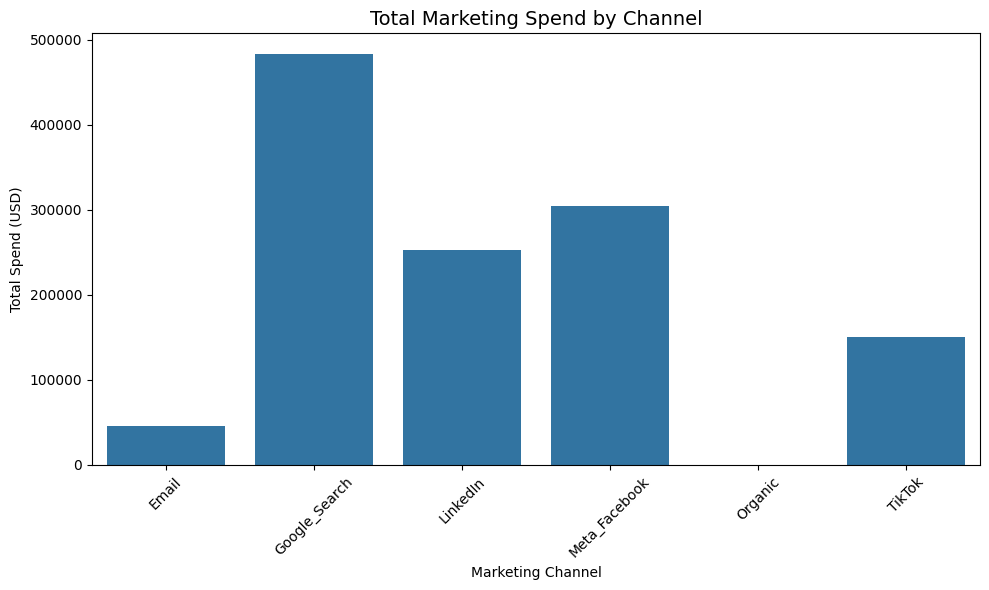

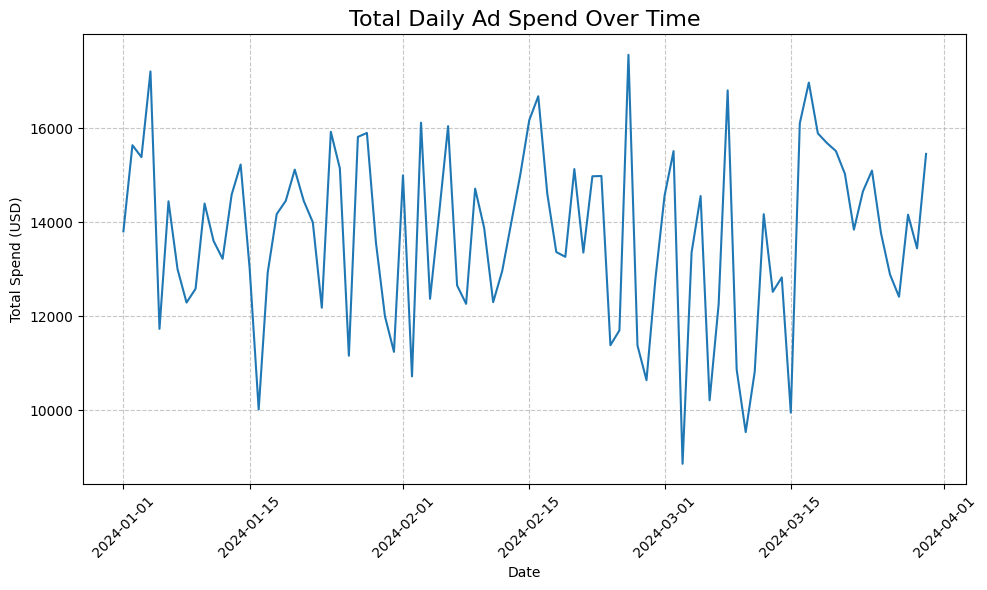

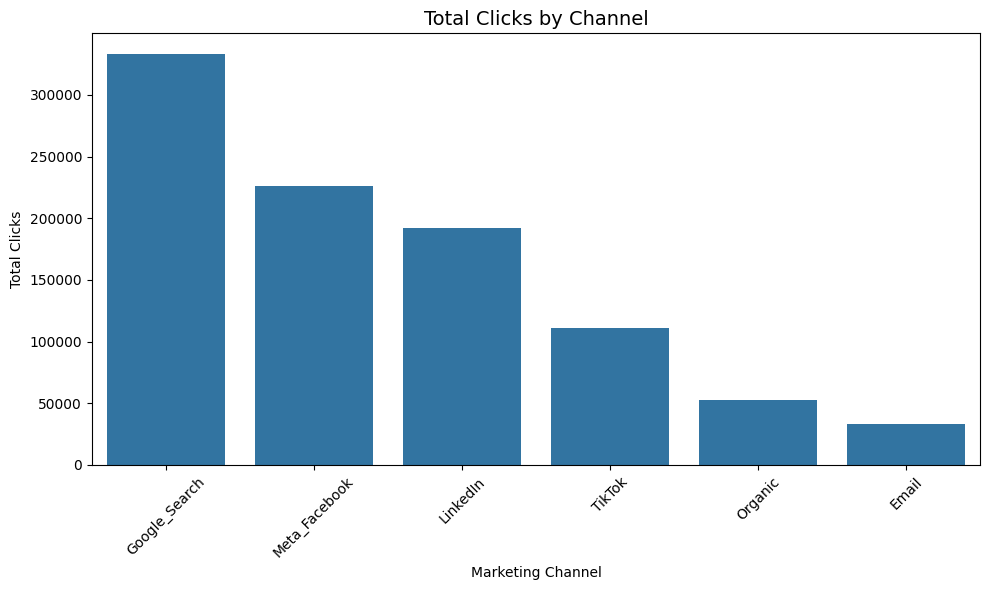

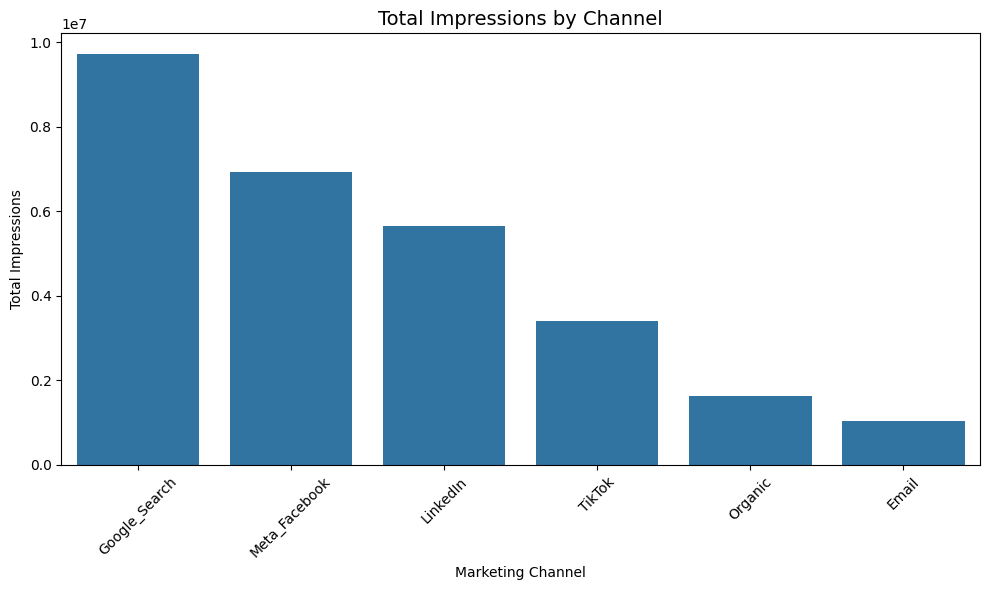

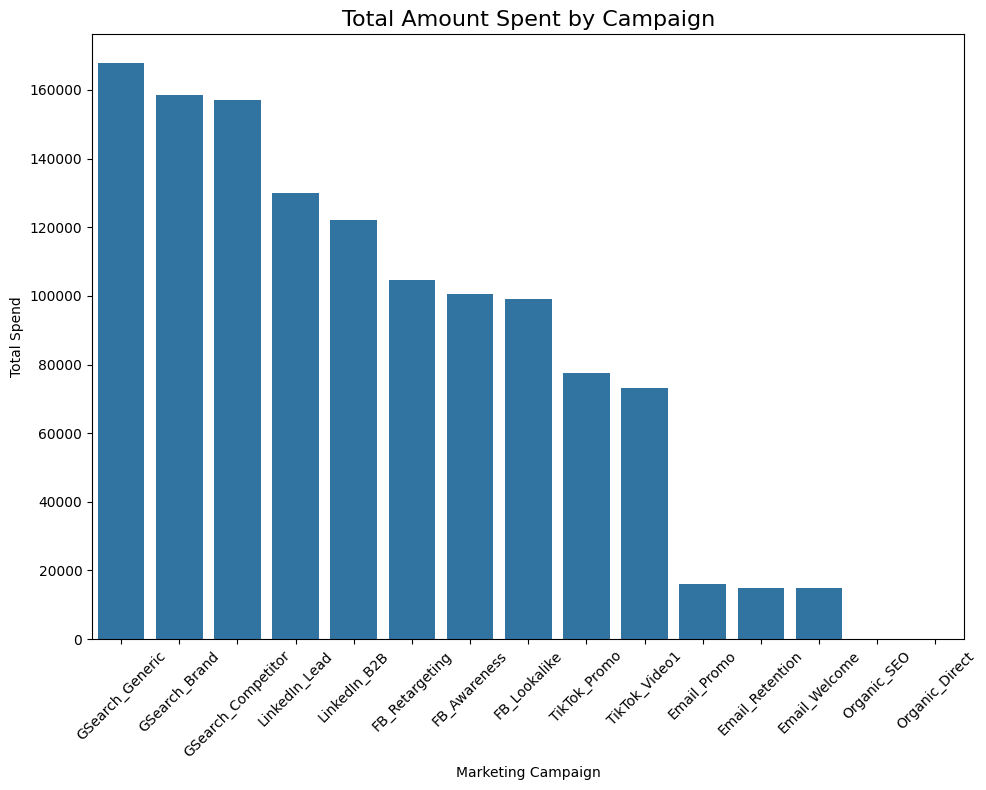

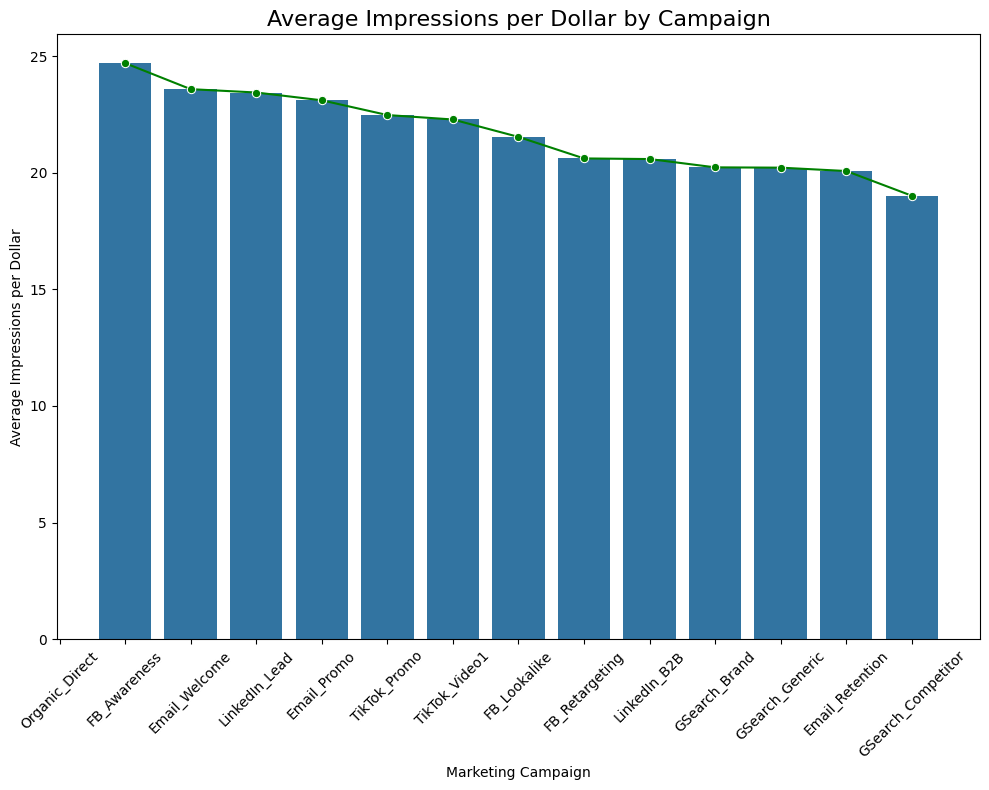

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
ad_spend_df = pd.read_csv("ad_spend_data.csv")
ad_spend_df.head()
ad_spend_df.columns
len(ad_spend_df)
type(ad_spend_df)
ad_spend_df.shape
ad_spend_df.info()
ad_spend_df.describe()
ad_spend_df.head(10)
ad_spend_df["channel"].unique()
ad_spend_df["channel"].nunique()
ad_spend_df["campaign"].nunique()
ad_spend_df["amount_spent_usd"].idxmax()
ad_spend_df.iloc[1006]
ad_spend_df["amount_spent_usd"].idxmin()
ad_spend_df.iloc[[13,14,1006]]
ad_spend_df[(ad_spend_df["amount_spent_usd"]==0)]["campaign"].unique()
ad_spend_df.head()
ad_spend_df["impressions"].mean()
ad_spend_df[(ad_spend_df["impressions"]>=15000)]["campaign"].nunique()
##ad_spend_df.isnull().sum()
ad_spend_df.isna().sum()
ad_spend_df.head()
ad_spend_df.groupby("campaign")[["clicks","cpc"]].sum().sort_values(by="clicks",ascending=False)
ad_spend_df["channel"].unique()
ad_spend_df["channel"].nunique()
ad_spend_df.groupby("channel")["amount_spent_usd"].sum().sort_values(ascending=False)
ad_spend_df.groupby("channel")["amount_spent_usd"].mean().sort_values(ascending=False)
ad_spend_df["cost_per_click"] = ad_spend_df["amount_spent_usd"] / ad_spend_df["clicks"]
ad_spend_df["cost_per_click"].head(2)
ad_spend_df.head(2)
ad_spend_df["impressions"].quantile([0.25,0.5,0.75])
ad_spend_df["amount_spent_usd"].corr(ad_spend_df["impressions"])
ad_spend_df[(ad_spend_df["impressions"]>=12911)]["amount_spent_usd"].mean()
ad_spend_df["cpc"].corr(ad_spend_df["amount_spent_usd"])
ad_spend_df["date"] = pd.to_datetime(ad_spend_df["date"])
ad_spend_df["date"].head(5)
ad_spend_df["time"] = pd.to_datetime(ad_spend_df["date"])
(ad_spend_df["time"]).info()
ad_spend_df["month"]=ad_spend_df["time"].dt.month
ad_spend_df["day"] = ad_spend_df["time"].dt.day_name()
ad_spend_df["month"]=ad_spend_df["time"].dt.month
ad_spend_df["day"].unique()
ad_spend_df["day"].nunique()
ad_spend_df["month"].nunique()
ad_spend_df.groupby(["month","day"])["amount_spent_usd"].mean()
ad_spend_df.groupby(["day","month"])["amount_spent_usd"].sum().sort_index(level="day",ascending=False)
ad_spend_df.head(3)
ad_spend_df["impressions_per_dollar"]=ad_spend_df["impressions"] / ad_spend_df["amount_spent_usd"]
ad_spend_df.groupby("campaign")["impressions_per_dollar"].mean().sort_values(ascending=False)
ad_spend_df.head(2)
total_clicks= ad_spend_df.groupby(["campaign","channel"])["clicks"].sum()
total_impressions= ad_spend_df.groupby(["campaign","channel"])["impressions"].sum()
click_through_rate= (total_clicks/total_impressions)*100
click_through_rate=click_through_rate.sort_values(ascending=False)
click_through_rate
ad_spend_df.head(1)
grouped_cost=ad_spend_df.groupby(["campaign","channel"])["amount_spent_usd"].sum()
grouped_impressions=ad_spend_df.groupby(["campaign","channel"])["impressions"].sum()
cost_per_mille=(grouped_cost/grouped_impressions)*1000
cost_per_mille = cost_per_mille.astype(float).sort_values(ascending=False)
cost_per_mille.reset_index(name='cost_per_mille')
ad_spend_df.head(2)
ad_spend_df.groupby("campaign")["cpc"].sum().sort_values(ascending=False).reset_index()
ad_spend_df["impressions"].idxmax()
ad_spend_df["impressions"].idxmin()
ad_spend_df.groupby("campaign")["impressions"].sum().sort_values(ascending=False).reset_index()
ad_spend_df.groupby("channel")["impressions"].sum().sort_values(ascending=False).reset_index()
##VISUALISATIONS
channel_spend = ad_spend_df.groupby("channel")["amount_spent_usd"].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data =channel_spend,x="channel",y="amount_spent_usd")
plt.title("Total Marketing Spend by Channel", fontsize=14)
plt.xlabel("Marketing Channel")
plt.ylabel("Total Spend (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

daily_spend = ad_spend_df.groupby('date')['amount_spent_usd'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='amount_spent_usd', data=daily_spend)
plt.title('Total Daily Ad Spend Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Spend (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

channel_clicks = (ad_spend_df.groupby("channel")["clicks"].sum().sort_values(ascending=False).reset_index())
plt.figure(figsize=(10,6))
sns.barplot(data=channel_clicks,x="channel",y="clicks")
plt.title("Total Clicks by Channel", fontsize=14)
plt.xlabel("Marketing Channel")
plt.ylabel("Total Clicks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

channel_impressions= ad_spend_df.groupby("channel")["impressions"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=channel_impressions, x="channel",y="impressions")
plt.title("Total Impressions by Channel", fontsize=14)
plt.xlabel("Marketing Channel")
plt.ylabel("Total Impressions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

campaign_spend =ad_spend_df.groupby("campaign")["amount_spent_usd"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,8))
sns.barplot(data=campaign_spend, x="campaign",y="amount_spent_usd")
plt.title("Total Amount Spent by Campaign", fontsize=16)
plt.xlabel("Marketing Campaign")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

avg_campaign_impressions_per_dollar =(ad_spend_df.groupby("campaign")["impressions_per_dollar"].mean().sort_values(ascending=False).reset_index())
plt.figure(figsize=(10,8))
sns.barplot(data=avg_campaign_impressions_per_dollar,x="campaign",y="impressions_per_dollar")
sns.lineplot(data=avg_campaign_impressions_per_dollar,x="campaign",y="impressions_per_dollar",color="green",marker="o")
plt.title("Average Impressions per Dollar by Campaign", fontsize=16)
plt.xlabel("Marketing Campaign")
plt.ylabel("Average Impressions per Dollar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6034 entries, 0 to 6033
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   session_id            6034 non-null   object        
 1   user_id               6034 non-null   object        
 2   timestamp             6034 non-null   object        
 3   channel               6034 non-null   object        
 4   utm_source            5434 non-null   object        
 5   utm_medium            6034 non-null   object        
 6   utm_campaign          5735 non-null   object        
 7   page_visited          6034 non-null   object        
 8   session_duration_sec  6034 non-null   int64         
 9   device                6034 non-null   object        
 10  date                  6034 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 518.7+ KB
Average time spent is 1.9097962808687043 more than average time spen

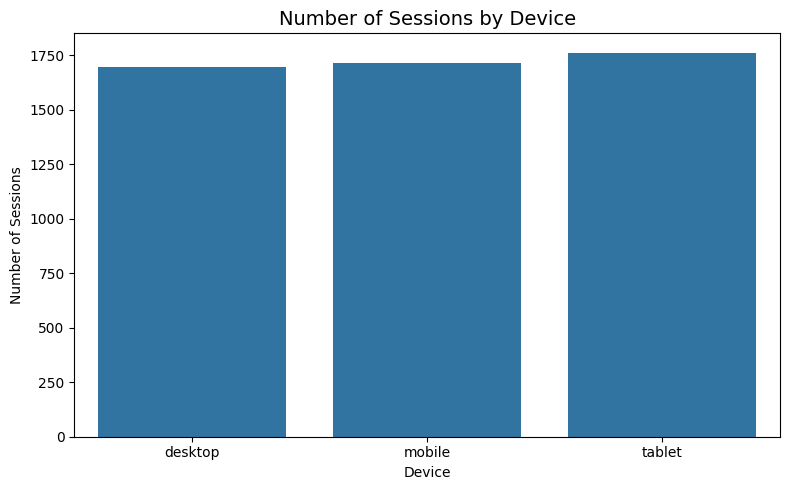

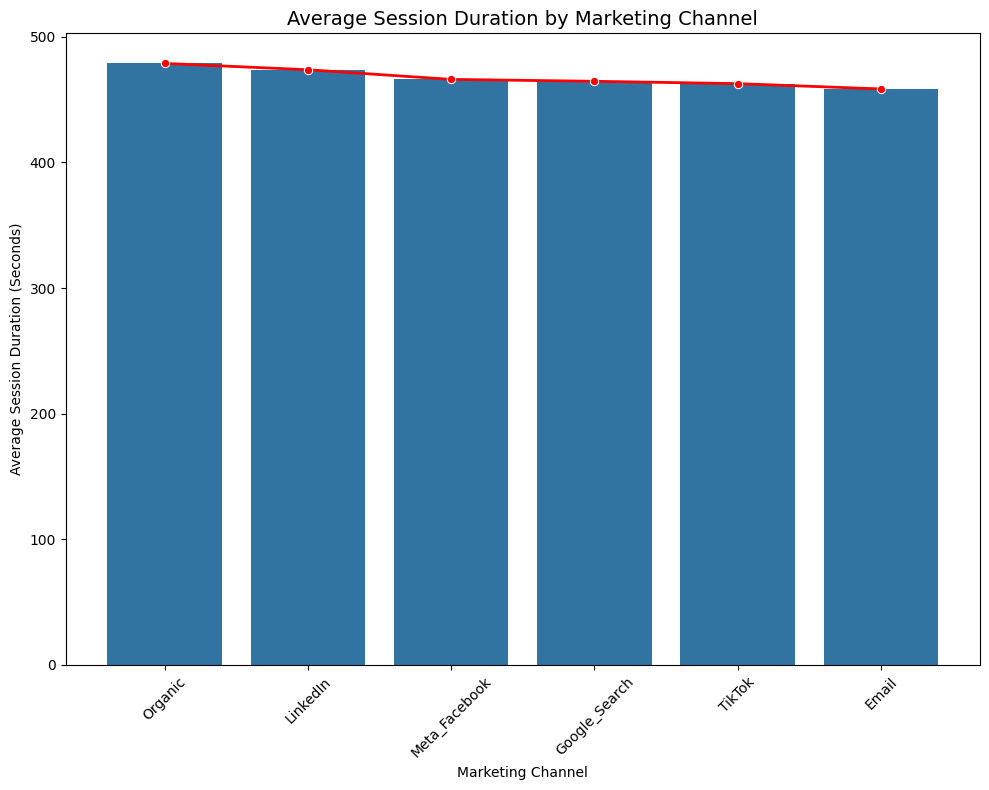

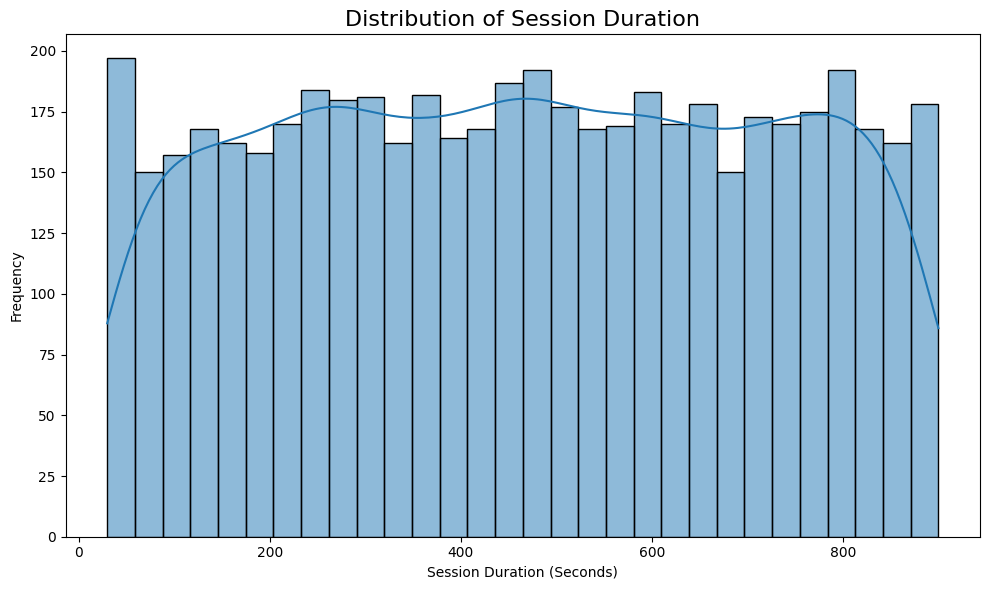

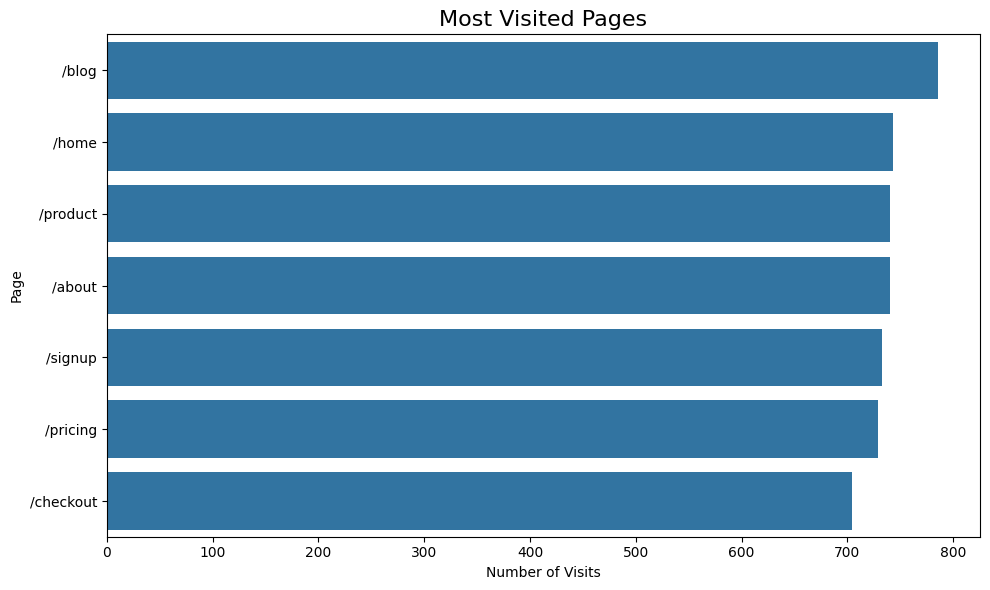

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
web_log_df=pd.read_csv("web_analytics_log.csv")
web_log_df.columns
web_log_df.head()
web_log_df["session_duration_sec"].describe()
web_log_df.head()
web_log_df["utm_medium"].nunique()
web_log_df.groupby(["utm_medium","device"])["session_duration_sec"].sum().sort_values(ascending=False)
web_log_df.head()
web_log_df["date"]=pd.to_datetime(web_log_df["timestamp"])
web_log_df.info()
web_log_df["date"].dt.day
web_log_df["date"].dt.day_name()
web_log_df["channel"].value_counts()
web_log_df.groupby("channel")["session_duration_sec"].mean().sort_values(ascending=False)
web_log_df["day"]=web_log_df["date"].dt.day_name()
web_log_df.groupby("day")["session_duration_sec"].sum().sort_values(ascending=False)
web_log_df["quarter"]=web_log_df["date"].dt.quarter
web_log_df.groupby("quarter")["session_duration_sec"].mean().sort_values(ascending=False)
web_log_df["utm_source"].nunique()
web_log_df["utm_source"].value_counts()
web_log_df.groupby("utm_source")["session_duration_sec"].mean().sort_values(ascending=False)
web_log_df.head()
web_log_df.groupby("day")["session_duration_sec"].sum().sort_values(ascending=False)
web_log_df.groupby("day")["session_duration_sec"].mean().sort_values(ascending=False)
web_log_df.isna().sum()
web_log_df.dropna(inplace=True)
##web_log_df.isna().sum()
len(web_log_df["utm_campaign"])
web_log_df["utm_source"].isna().sum()
web_log_df.groupby("user_id")["session_id"].count()
web_log_df.groupby(["utm_campaign","device"])["session_duration_sec"].sum().sort_values(ascending=False).reset_index()
web_log_df.groupby(["utm_campaign","device"])["session_duration_sec"].mean().sort_values(ascending=False).reset_index()
web_log_df["user_id"].nunique()
repeated_users = web_log_df['user_id'].value_counts()
repeated_users.sort_values(ascending=False)
web_log_df[(web_log_df["user_id"]=="USR_00405")].head(3)
web_log_df.sort_values(["user_id","utm_campaign"]).head(3)
first_touch = web_log_df.sort_values(["user_id","utm_campaign"]).groupby("user_id").first()
web_log_df.head(2)
first_touch[["channel","utm_campaign"]].head()
first_touch["channel"].value_counts()
web_log_df["user_id"].nunique()
web_log_df.sort_values(["user_id","utm_medium"]).groupby("user_id")
first_touch=web_log_df.sort_values(["user_id","utm_medium"]).groupby("user_id").first()
first_touch[["timestamp","utm_campaign","utm_source"]].head(10)
a=first_touch["session_duration_sec"].mean()
b=web_log_df["session_duration_sec"].mean()
c= b-a
c
print("Average time spent is", c,"more than average time spent for the first time interaction")
web_log_df.head(3)
web_log_df["page_visited"].nunique()
web_log_df.groupby(["page_visited"])["session_duration_sec"].agg(['sum','mean'])
web_log_df.groupby(["page_visited","device"])["session_duration_sec"].agg(['sum','mean'])
web_log_df.head(2)
web_log_df.sort_values(["user_id","date","timestamp"])
first_touch_attribution = web_log_df.groupby("user_id").first()
first_touch_attribution.head(3)
##VISUALISATIONS
##1-->Sessions per device
plt.figure(figsize=(8,5))
sns.countplot(data=web_log_df,x="device")
plt.title("Number of Sessions by Device", fontsize=14)
plt.xlabel("Device")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()
##2-->Average session duration by channel
avg_session_duration = (web_log_df.groupby("channel")["session_duration_sec"].mean().sort_values(ascending=False).reset_index())
plt.figure(figsize=(10,8))
sns.barplot(data=avg_session_duration,x="channel",y="session_duration_sec")
sns.lineplot(data=avg_session_duration,x="channel",y="session_duration_sec",color="red",marker="o",linewidth=2)
plt.title("Average Session Duration by Marketing Channel", fontsize=14)
plt.xlabel("Marketing Channel")
plt.ylabel("Average Session Duration (Seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##3-->Session Duration Distribution
plt.figure(figsize=(10,6))
sns.histplot(data=web_log_df,x="session_duration_sec",bins=30,kde=True)
plt.title("Distribution of Session Duration",fontsize=16)
plt.xlabel("Session Duration (Seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##4-->Most Visited Pages
top_pages =(web_log_df["page_visited"].value_counts().reset_index())
top_pages.columns=["page_visited","count"]
plt.figure(figsize=(10,6))
sns.barplot(data=top_pages,y="page_visited",x="count")
plt.title("Most Visited Pages",fontsize=16)
plt.xlabel("Number of Visits")
plt.ylabel("Page")
plt.tight_layout()
plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          600 non-null    object        
 1   conversion_date      600 non-null    datetime64[ns]
 2   revenue_usd          600 non-null    float64       
 3   last_touch_channel   600 non-null    object        
 4   last_touch_campaign  572 non-null    object        
 5   product_purchased    600 non-null    object        
 6   country              600 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 32.9+ KB


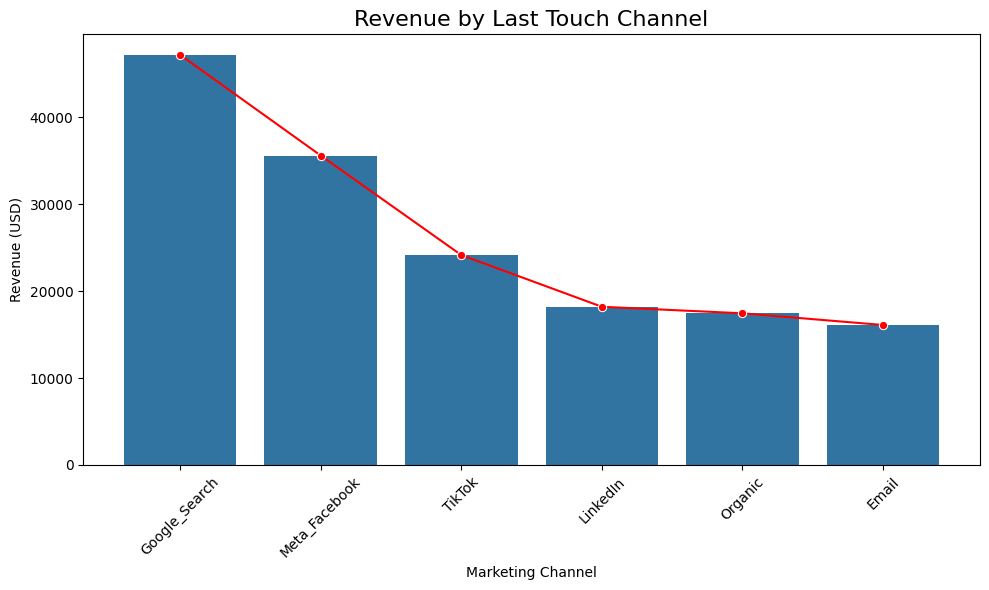

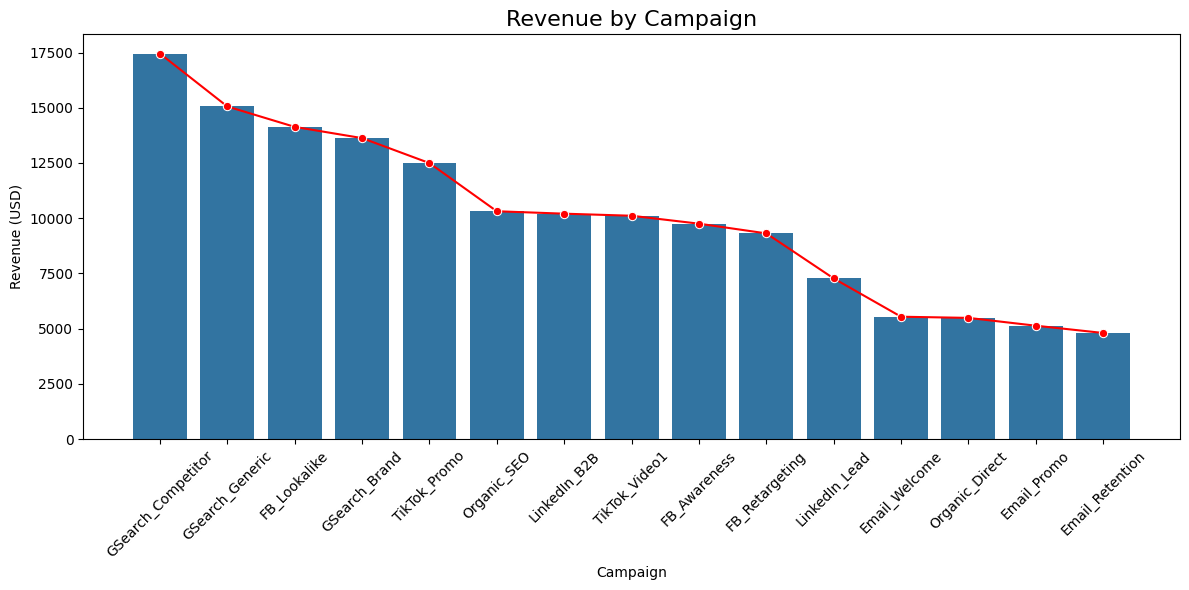

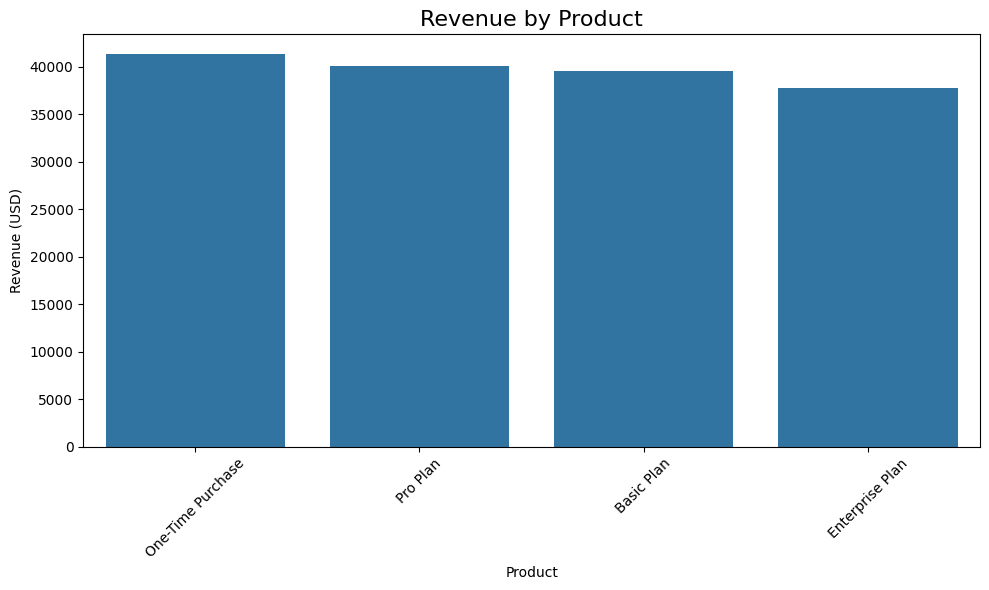

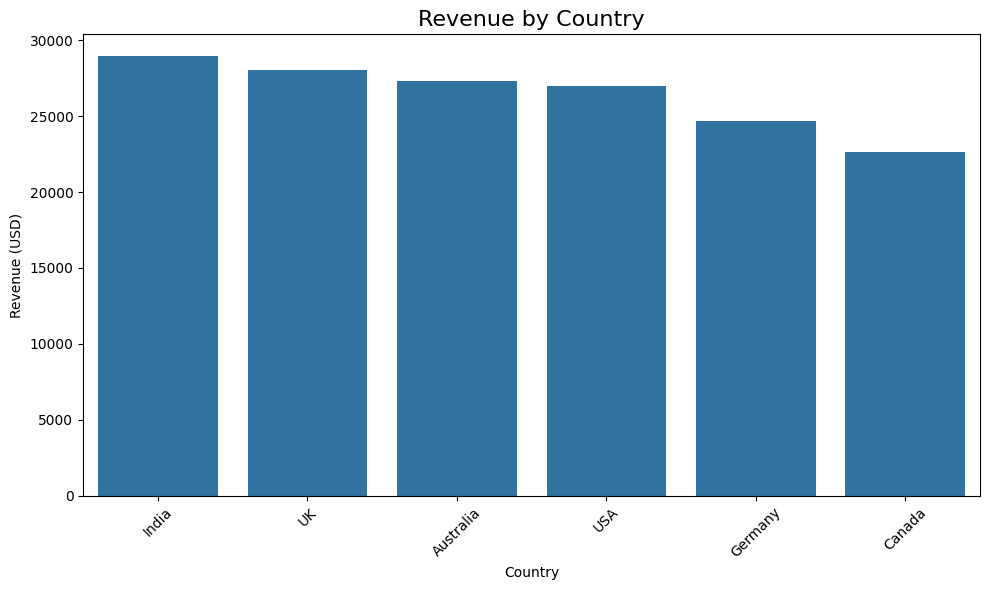

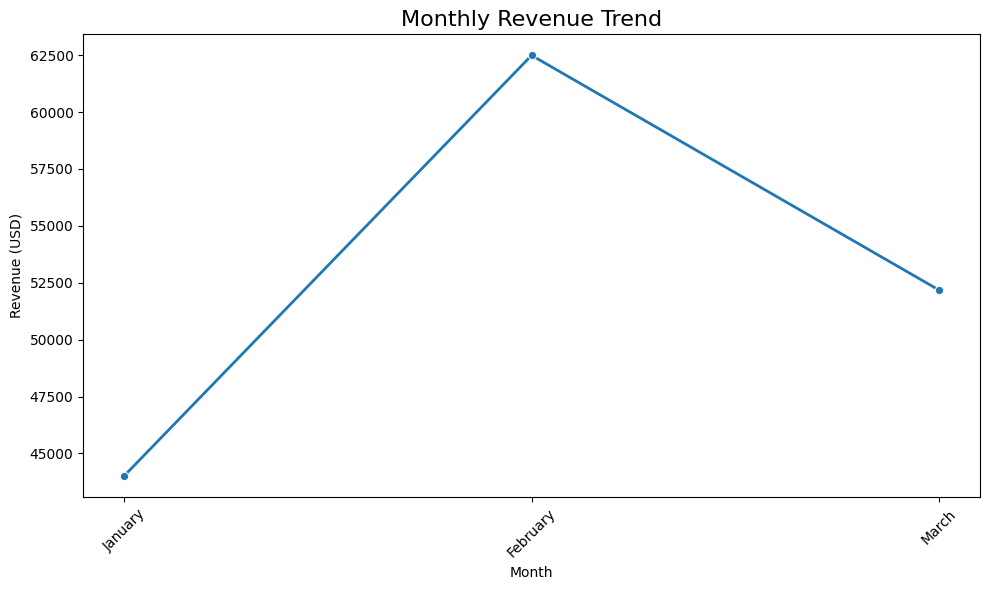

In [7]:
import pandas as pd
crm_df=pd.read_csv("crm_conversion_data.csv")
crm_df.head()
crm_df[(crm_df["country"]=="Australia")]["revenue_usd"].sum()
crm_df["customer_id"].nunique()
crm_df.columns
crm_df.groupby("country")["revenue_usd"].sum().sort_values(ascending=False)
crm_df.head()
crm_df["last_touch_campaign"].nunique()
crm_df[(crm_df["last_touch_campaign"]=="TikTok_Video1") & (crm_df["last_touch_channel"]=="Tiktok")]
##crm_df["last_touch_campaign"].nunique()
crm_df.groupby("last_touch_channel")["revenue_usd"].sum().sort_values(ascending=False)
##Product Purchase Frequency: Determine the most frequently purchased products.
crm_df["product_purchased"].min()
##crm_df[(crm_df["product_purchased"]=="Pro Plan")]["conversion_date"].nunique()
##crm_df.groupby("product_purchased")["conversion_date"].nunique().sort_values(ascending=False)
crm_df[(crm_df["product_purchased"]=="Basic Plan")].nunique()
##Distribution of Revenue per Conversion
crm_df.head()
crm_df.groupby("product_purchased")["revenue_usd"].sum().sort_values(ascending=False)
rev =crm_df["revenue_usd"].sum()
prod =crm_df["product_purchased"].count()
b=rev/prod
crm_df["product_purchased"].isna().sum()
b
crm_df.head()
crm_df.groupby("last_touch_channel")["revenue_usd"].sum().sort_values(ascending=False)
crm_df["conversion_date"]=pd.to_datetime(crm_df["conversion_date"])
crm_df.info()
crm_df["conversion_month"]=crm_df["conversion_date"].dt.month
crm_df.groupby("conversion_month")["revenue_usd"].sum().sort_values(ascending=False)
crm_df["conversion_day"]=crm_df["conversion_date"].dt.day_name()
crm_df["conversion_day"]
crm_df.groupby(["conversion_day","product_purchased"])["revenue_usd"].sum().sort_values(ascending=False).reset_index()
crm_df.head(3)
crm_df.groupby("last_touch_campaign")["revenue_usd"].agg(['sum','mean']).sort_values(by='mean', ascending=False).reset_index()
crm_df.groupby("country")["revenue_usd"].mean().sort_values(ascending=False)
crm_df.columns

##VISUALISATIONS
##1 Revenue from last touch channel
revenue_channel =crm_df.groupby("last_touch_channel")["revenue_usd"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=revenue_channel,x="last_touch_channel",y="revenue_usd")
sns.lineplot(data=revenue_channel,x="last_touch_channel",y="revenue_usd",color="red",marker="o")
plt.title("Revenue by Last Touch Channel", fontsize=16)
plt.xlabel("Marketing Channel")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Revenue By Campaign
revenue_campaign = crm_df.groupby("last_touch_campaign")["revenue_usd"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=revenue_campaign,x="last_touch_campaign",y="revenue_usd")
sns.lineplot(data=revenue_campaign,x="last_touch_campaign",y="revenue_usd",color="red",marker="o")
plt.title("Revenue by Campaign", fontsize=16)
plt.xlabel("Campaign")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Revenue By Product Purchased
product_revenue = crm_df.groupby("product_purchased")["revenue_usd"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=product_revenue,x="product_purchased",y="revenue_usd")
plt.title("Revenue by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Revenue By Country
country_revenue =crm_df.groupby("country")["revenue_usd"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=country_revenue,x="country",y="revenue_usd")
plt.title("Revenue by Country", fontsize=16)
plt.xlabel("Country")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Revenue By Month
monthly_revenue = crm_df["month_name"] = crm_df["conversion_date"].dt.month_name()
monthly_revenue = crm_df.groupby("month_name")["revenue_usd"].sum().reindex(["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]).reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_revenue,x="month_name",y="revenue_usd",marker="o",linewidth=2)
plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:

import pandas as pd
crm_df = pd.read_csv("crm_conversion_data.csv")
crm_df.head()
crm_df[(crm_df["country"]=="Australia")]["revenue_usd"].sum()
crm_df["customer_id"].nunique()
crm_df.columns
crm_df.groupby("country")["revenue_usd"].sum().sort_values(ascending=False)
crm_df.head()
##crm_df["last_touch_campaign"].nunique()
##1 Revenue Distribution by Last Touch Channel: Analyze which marketing channels are most effective in driving conversions and revenue.
crm_df.groupby("last_touch_channel")["revenue_usd"].sum().sort_values(ascending=False)
crm_df.tail(2)
crm_df["product_purchased"].value_counts()
crm_df["product_purchased"].nunique()
crm_df["revenue_usd"].sum()
crm_df["conversion_date"].nunique()
avg_rev_per_day=crm_df["revenue_usd"].sum()/crm_df["conversion_date"].nunique()
crm_df.tail(2)
crm_df.sort_values(["customer_id","conversion_date"])
last_touch_attribution= crm_df.groupby("customer_id").last()
last_touch_attribution.tail(2)
revenue_from_last_touch_attribution= last_touch_attribution.groupby("last_touch_channel")["revenue_usd"].sum().sort_values(ascending=False)
contribution_percentage_to_total_revenue =(revenue_from_last_touch_attribution/crm_df["revenue_usd"].sum())*100
contribution_percentage_to_total_revenue


,revenue_usd
last_touch_channel,
Google_Search,29.733802
Meta_Facebook,22.433662
TikTok,15.219854
LinkedIn,11.468801
Organic,10.995706
Email,10.148176


In [ ]:
lastproduct_frequency = crm_df['product_purchased'].value_counts()
product_frequency


,count
product_purchased,
One-Time Purchase,163
Basic Plan,150
Enterprise Plan,144
Pro Plan,143


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
ad_spend_copy=ad_spend_df.copy()
web_log_copy=web_log_df.copy()
crm_copy=crm_df.copy()
crm_copy.head(2)
ad_summary = ad_spend_df.groupby(["channel", "campaign"], as_index=False).agg(total_spend=("amount_spent_usd", "sum"),total_clicks=("clicks", "sum"),total_impressions=("impressions", "sum"))
web_summary = web_log_df.groupby(["channel", "utm_campaign"], as_index=False).agg(total_sessions=("session_id", "nunique"),avg_session_duration=("session_duration_sec", "mean"))
crm_summary = crm_df.groupby(["last_touch_channel", "last_touch_campaign"], as_index=False).agg(total_revenue=("revenue_usd", "sum"),total_customers=("customer_id", "nunique"))
marketing_performance_df =ad_summary.merge(web_summary,left_on=["channel", "campaign"],right_on=["channel", "utm_campaign"],how="left").merge(crm_summary,left_on=["channel", "campaign"],right_on=["last_touch_channel", "last_touch_campaign"],how="left")
marketing_performance_df.head(3)
marketing_performance_df.columns
(marketing_performance_df["channel"] == marketing_performance_df["last_touch_channel"]).all()
(marketing_performance_df["campaign"] == marketing_performance_df["utm_campaign"]).all()
(marketing_performance_df["campaign"] == marketing_performance_df["last_touch_campaign"]).all()
marketing_performance_df.drop(columns=["utm_campaign","last_touch_channel","last_touch_campaign"], inplace=True)
marketing_performance_df.head(2)
cac= marketing_performance_df["total_spend"].sum() / marketing_performance_df["total_customers"].sum()
print("Cost Of Acquiring Customer", cac)
marketing_performance_df.head(2)
roas= marketing_performance_df["total_revenue"].sum()/marketing_performance_df["total_spend"].sum()
roas
print(f" ROAS: {roas:.2f}x")
channelwise_roas=marketing_performance_df.groupby("channel")["total_revenue"].sum()/marketing_performance_df.groupby("channel")["total_spend"].sum()
channelwise_roas.sort_values(ascending=False).reset_index()
campaignwise_roas=marketing_performance_df.groupby("campaign")["total_revenue"].sum()/marketing_performance_df.groupby("campaign")["total_spend"].sum()
campaignwise_roas.sort_values(ascending=False).reset_index()
##Conversion Rate
marketing_performance_df.head()
revenue_by_channel=marketing_performance_df.groupby("channel")["total_revenue"].sum()
spend_by_channel=marketing_performance_df.groupby("channel")["total_spend"].sum()
channelwise_roas=revenue_by_channel/spend_by_channel
channelwise_roas
##CAC by Channel
channelwise_cac = marketing_performance_df.groupby("channel")["total_spend"].sum()/marketing_performance_df.groupby("channel")["total_customers"].sum()
channelwise_cac.sort_values(ascending=False).reset_index()

##Conversion Rate
marketing_performance_df.head()
conversion_rate =marketing_performance_df["total_customers"].sum()/marketing_performance_df["total_sessions"].sum()
conversion_rate
channelwise_conversion_rate = marketing_performance_df.groupby("channel")["total_customers"].sum()/marketing_performance_df.groupby("channel")["total_sessions"].sum()
channelwise_conversion_rate.sort_values(ascending=False).reset_index()
campaignwise_conversion_rate = marketing_performance_df.groupby("campaign")["total_customers"].sum()/marketing_performance_df.groupby("campaign")["total_sessions"].sum()
campaignwise_conversion_rate.sort_values(ascending=False).reset_index()
##Revenue per Session
revenue_per_session = marketing_performance_df["total_revenue"].sum()/marketing_performance_df["total_sessions"].sum()
revenue_per_session
##Revenue per Customer
marketing_performance_df.head()
revenue_per_customer= marketing_performance_df["total_revenue"].sum()/marketing_performance_df["total_customers"].sum()
revenue_per_customer
channelwise_revenue_per_customer = marketing_performance_df.groupby("channel")["total_revenue"].sum()/marketing_performance_df.groupby("channel")["total_customers"].sum()
channelwise_revenue_per_customer.sort_values(ascending=False).reset_index()
campaignwise_revenue_per_customer = marketing_performance_df.groupby("campaign")["total_revenue"].sum()/marketing_performance_df.groupby("campaign")["total_customers"].sum()
campaignwise_revenue_per_customer

##Cost per session
marketing_performance_df.head()
cost_per_session=marketing_performance_df["total_spend"].sum()/marketing_performance_df["total_sessions"].sum()
cost_per_session
channelwise_cost_per_session = marketing_performance_df.groupby("channel")["total_spend"].sum()/marketing_performance_df.groupby("channel")["total_sessions"].sum()
channelwise_cost_per_session
marketing_performance_df.head()
campaignwise_cost_per_session = marketing_performance_df.groupby("campaign")["total_spend"].sum()/marketing_performance_df.groupby("campaign")["total_sessions"].sum()
campaignwise_cost_per_session.sort_values(ascending=False).reset_index()


Cost Of Acquiring Customer 2161.130244755245
 ROAS: 0.12x


,campaign,0
0,LinkedIn_Lead,498.574674
1,LinkedIn_B2B,484.266865
2,GSearch_Generic,349.640833
3,GSearch_Brand,330.734823
4,GSearch_Competitor,302.607129
5,FB_Retargeting,247.622370
6,FB_Awareness,232.070993
7,FB_Lookalike,214.800368
8,TikTok_Video1,191.754593
9,TikTok_Promo,189.514866


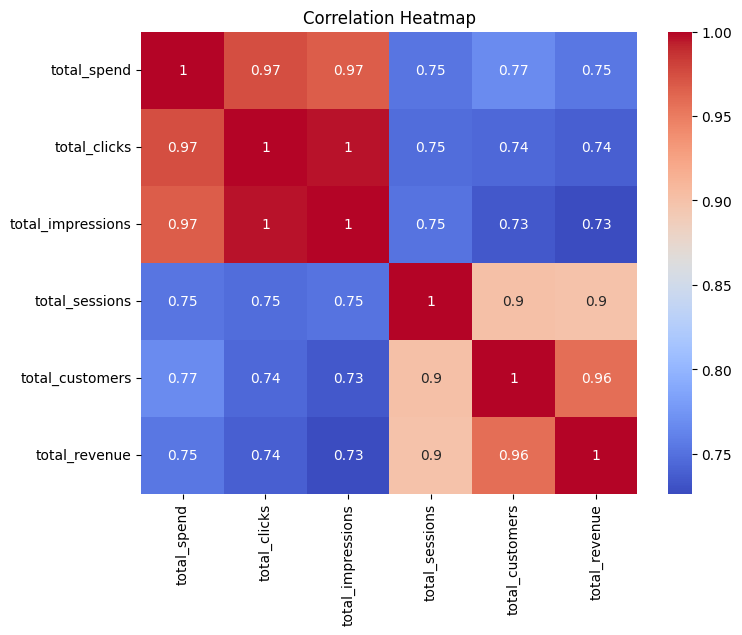

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
corr = marketing_performance_df[['total_spend','total_clicks','total_impressions','total_sessions','total_customers','total_revenue']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()